---
## 1. 📦 Install Dependencies

In [1]:
!pip install -q tensorflow tensorflow-datasets pillow numpy matplotlib
!pip install -q scikit-learn seaborn wandb
!pip install -q gradio pyngrok
!pip install -q fastapi uvicorn[standard] python-multipart

import os
os.environ['GRADIO_ANALYTICS_ENABLED'] = 'False'
print('✅ All packages installed.')


✅ All packages installed.


---
## 2. 📥 Load Dataset

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

print('📥 Downloading PlantVillage dataset...')

(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

all_labels     = ds_info.features['label'].names
potato_indices = [i for i, name in enumerate(all_labels) if 'Potato' in name]
CLASS_NAMES    = [
    all_labels[i].replace('Potato___', '').replace('_', ' ').title()
    for i in potato_indices
]

print(f'\n🥔 Potato classes: {CLASS_NAMES}')


📥 Downloading PlantVillage dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.WKLJSB_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.

🥔 Potato classes: ['Early Blight', 'Healthy', 'Late Blight']


---
## 3. 🔧 Preprocess & Pipeline

In [8]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

KERAS_PATH = '/content/potato_disease_model.keras'

potato_tensor = tf.constant(potato_indices, dtype=tf.int64)

def is_potato(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), potato_tensor))

def remap_label(image, label):
    matches   = tf.equal(tf.cast(label, tf.int64), potato_tensor)
    new_label = tf.argmax(tf.cast(matches, tf.int32))
    return image, tf.cast(new_label, tf.int32)

def preprocess(image, label):
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def build_pipeline(ds, shuffle=False, repeat=False):
    ds = (ds
          .filter(is_potato)
          .map(remap_label, num_parallel_calls=AUTOTUNE)
          .map(preprocess, num_parallel_calls=AUTOTUNE)
          .cache())
    if repeat:
        ds = ds.repeat() # Add repeat here for training dataset
    if shuffle:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_pipeline(ds_train_raw, shuffle=True, repeat=True)
val_ds   = build_pipeline(ds_val_raw)
test_ds  = build_pipeline(ds_test_raw)

print(f'✅ Pipeline ready — {IMAGE_SIZE}×{IMAGE_SIZE}, batch={BATCH_SIZE}')
print(f'   Classes: {CLASS_NAMES}')

✅ Pipeline ready — 256×256, batch=32
   Classes: ['Early Blight', 'Healthy', 'Late Blight']


---
## 4. 🖼️ Visualise Sample Images

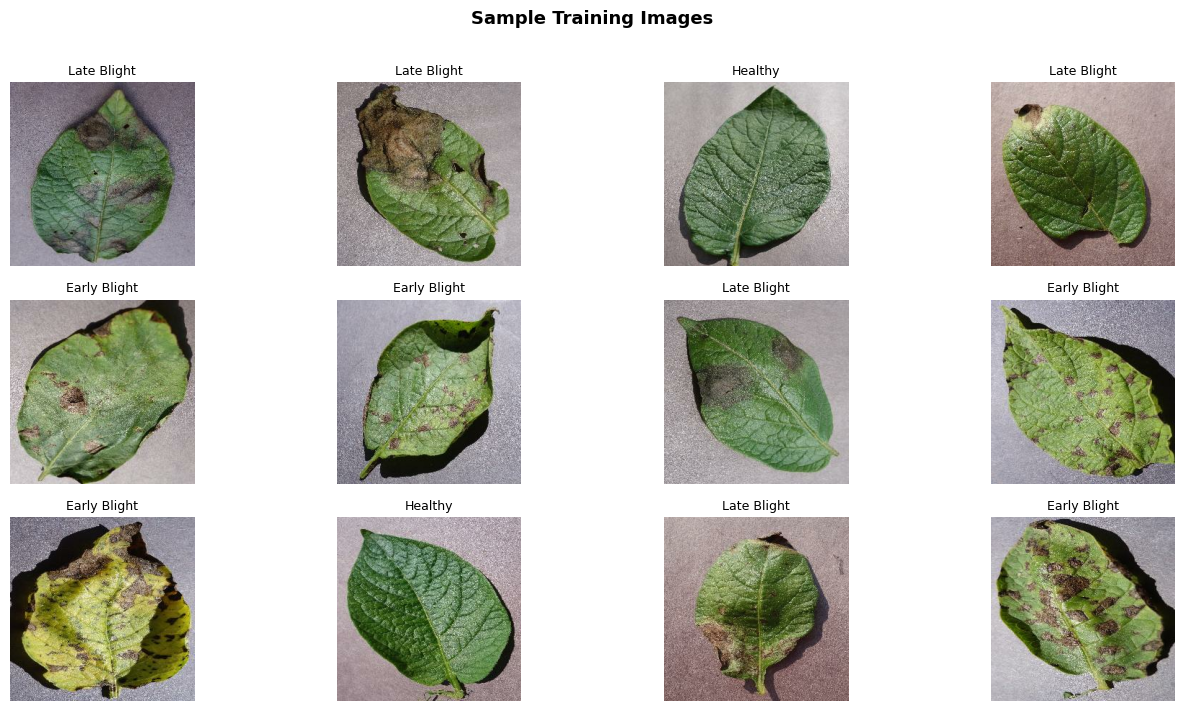

In [4]:
plt.figure(figsize=(14, 7))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(CLASS_NAMES[labels[i].numpy()], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 5. 🏗️ Build CNN Model

In [5]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name='augmentation')

def build_model(num_classes=3):
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = data_augmentation(inputs)
    for filters in [32, 64, 64, 64, 64, 64]:
        x = layers.Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='PotatoCNN')

model = build_model()
model.summary()


Model: "PotatoCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,899 (909.76 KB)

 Trainable params: 232,899 (909.76 KB)

 Non-trainable params: 0 (0.00 B)

---
## 6. 🔑 Load Secrets

Add these to **Colab Secrets** (🔑 left sidebar → `+ Add new secret`):

| Secret name | Where to get it |
|---|---|
| `NGROK_TOKEN` | [dashboard.ngrok.com](https://dashboard.ngrok.com/get-started/your-authtoken) |
| `WANDB_API_KEY` | [wandb.ai/authorize](https://wandb.ai/authorize) |


In [6]:
from google.colab import userdata
import os, wandb

NGROK_TOKEN   = userdata.get('NGROK_TOKEN')
WANDB_API_KEY = userdata.get('WANDB_API_KEY')

if not NGROK_TOKEN:
    print('⚠️  NGROK_TOKEN missing — add to Colab Secrets')
else:
    print('✅ NGROK_TOKEN loaded')

if not WANDB_API_KEY:
    print('⚠️  WANDB_API_KEY missing — add to Colab Secrets')
else:
    os.environ['WANDB_API_KEY'] = WANDB_API_KEY
    wandb.login(key=WANDB_API_KEY, relogin=True)
    print('✅ WANDB_API_KEY loaded & logged in')


✅ NGROK_TOKEN loaded


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shubhamp-shukla1010 (shubhamp-shukla1010-siksha-o-anusandhan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WANDB_API_KEY loaded & logged in


---
## 7. ⚙️ Compile & Train

In [7]:
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

EPOCHS = 25

# Class weights to handle Healthy class imbalance
all_train_labels = np.concatenate([y.numpy() for _, y in train_ds])
cw = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=all_train_labels)
class_weight_dict = dict(enumerate(cw))
print('Class weights:', {CLASS_NAMES[k]: round(v, 2) for k, v in class_weight_dict.items()})

wandb.init(
    project='potato-disease-cnn',
    config={
        'image_size': IMAGE_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'architecture': 'Custom CNN 6-block',
        'dataset': 'PlantVillage',
        'classes': CLASS_NAMES,
        'optimizer': 'adam',
        'class_weights': class_weight_dict,
    }
)

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    WandbMetricsLogger(log_freq='epoch'),
]

print(f'🚀 Training (up to {EPOCHS} epochs)...\n')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
)

wandb.finish()


Class weights: {'Early Blight': np.float64(0.72), 'Healthy': np.float64(4.69), 'Late Blight': np.float64(0.71)}


🚀 Training (up to 25 epochs)...

Epoch 1/25
     47/Unknown 215s 4s/step - accuracy: 0.3055 - loss: 1.1425

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


47/47 ━━━━━━━━━━━━━━━━━━━━ 233s 5s/step - accuracy: 0.3550 - loss: 1.0936 - val_accuracy: 0.5044 - val_loss: 0.9148 - learning_rate: 0.0010
Epoch 2/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6119 - loss: 1.0645

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


47/47 ━━━━━━━━━━━━━━━━━━━━ 242s 5s/step - accuracy: 0.6437 - loss: 0.9403 - val_accuracy: 0.7522 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 3/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 221s 5s/step - accuracy: 0.6597 - loss: 0.6808 - val_accuracy: 0.7551 - val_loss: 0.5137 - learning_rate: 0.0010
Epoch 4/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 262s 6s/step - accuracy: 0.7093 - loss: 0.5876 - val_accuracy: 0.7434 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 5/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.7877 - loss: 0.4174 - val_accuracy: 0.7930 - val_loss: 0.5302 - learning_rate: 0.0010
Epoch 6/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8329 - loss: 0.3769
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
47/47 ━━━━━━━━━━━━━━━━━━━━ 259s 6s/step - accuracy: 0.8252 - loss: 0.3835 - val_accuracy: 0.7464 - val_loss: 0.7875 - learning_rate: 0.0010
Epoch 7/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.8285 - loss: 0.3423 - val_accuracy: 0.8367 

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


47/47 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.8908 - loss: 0.2303 - val_accuracy: 0.6968 - val_loss: 0.9144 - learning_rate: 5.0000e-04
Epoch 10/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8965 - loss: 0.2057
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
47/47 ━━━━━━━━━━━━━━━━━━━━ 278s 6s/step - accuracy: 0.8995 - loss: 0.2092 - val_accuracy: 0.8426 - val_loss: 0.4021 - learning_rate: 5.0000e-04
Epoch 11/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.9149 - loss: 0.1945 - val_accuracy: 0.8076 - val_loss: 0.5523 - learning_rate: 2.5000e-04
Epoch 12/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 223s 5s/step - accuracy: 0.9250 - loss: 0.1661 - val_accuracy: 0.8542 - val_loss: 0.4678 - learning_rate: 2.5000e-04
Epoch 13/25
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9439 - loss: 0.1268
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
47/47 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.9370 - loss: 0.1423 - va

epoch/accuracy,▁▄▄▅▆▆▆▇▇▇▇▇▇██████████
epoch/epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
epoch/learning_rate,█████▄▄▄▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▅▅▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▆▆▅▆▅▇▇▅▇▇▇▆▇█▇▇█▇▇█▇▇
epoch/val_loss,█▄▃▄▃▆▂▃█▂▄▃▇▃▂▄▄▁▄▃▁▃▄
epoch/accuracy,0.97924
epoch/epoch,22
epoch/learning_rate,0.00013
epoch/loss,0.05203
epoch/val_accuracy,0.82507


---
## 8. 📊 Training History

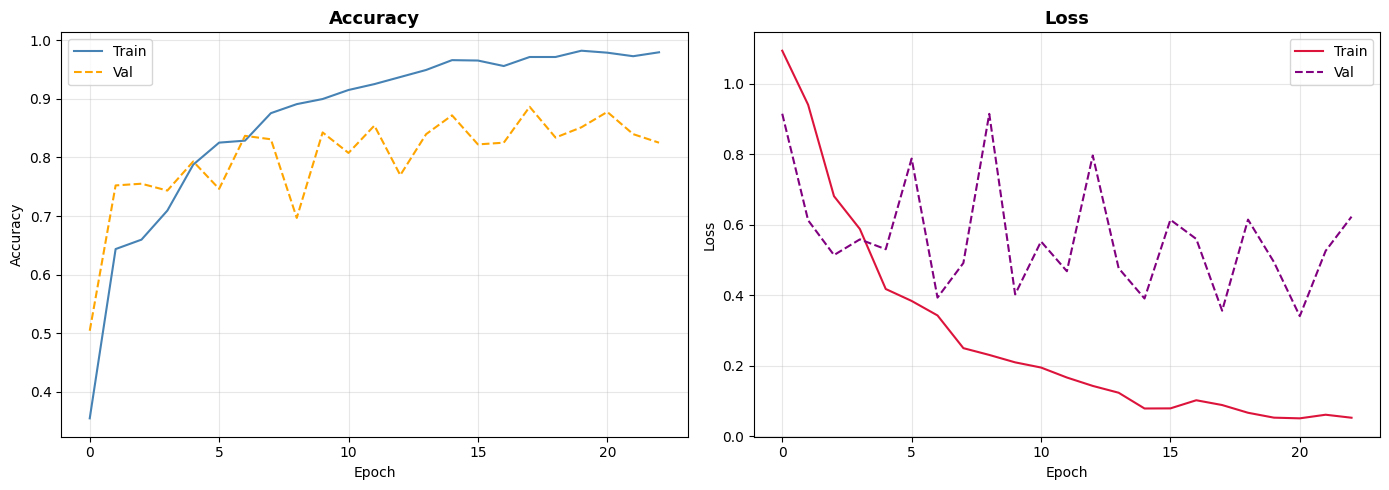

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange', linestyle='--')
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='crimson')
axes[1].plot(history.history['val_loss'], label='Val',   color='purple', linestyle='--')
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 9. 🧪 Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n{'='*40}")
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f"{'='*40}")



  Test Loss     : 0.2553
  Test Accuracy : 91.46%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


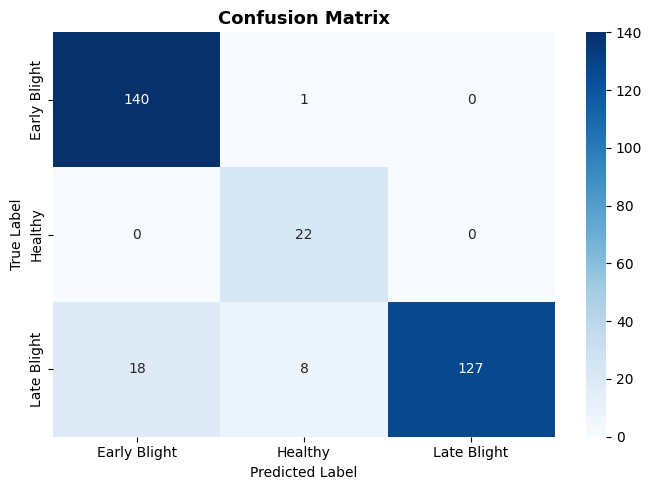


Classification Report:
              precision    recall  f1-score   support

Early Blight       0.89      0.99      0.94       141
     Healthy       0.71      1.00      0.83        22
 Late Blight       1.00      0.83      0.91       153

    accuracy                           0.91       316
   macro avg       0.87      0.94      0.89       316
weighted avg       0.93      0.91      0.91       316



In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred_all = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_all.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred_all)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred_all, target_names=CLASS_NAMES))


---
## 10. 🔍 Visualise Test Predictions

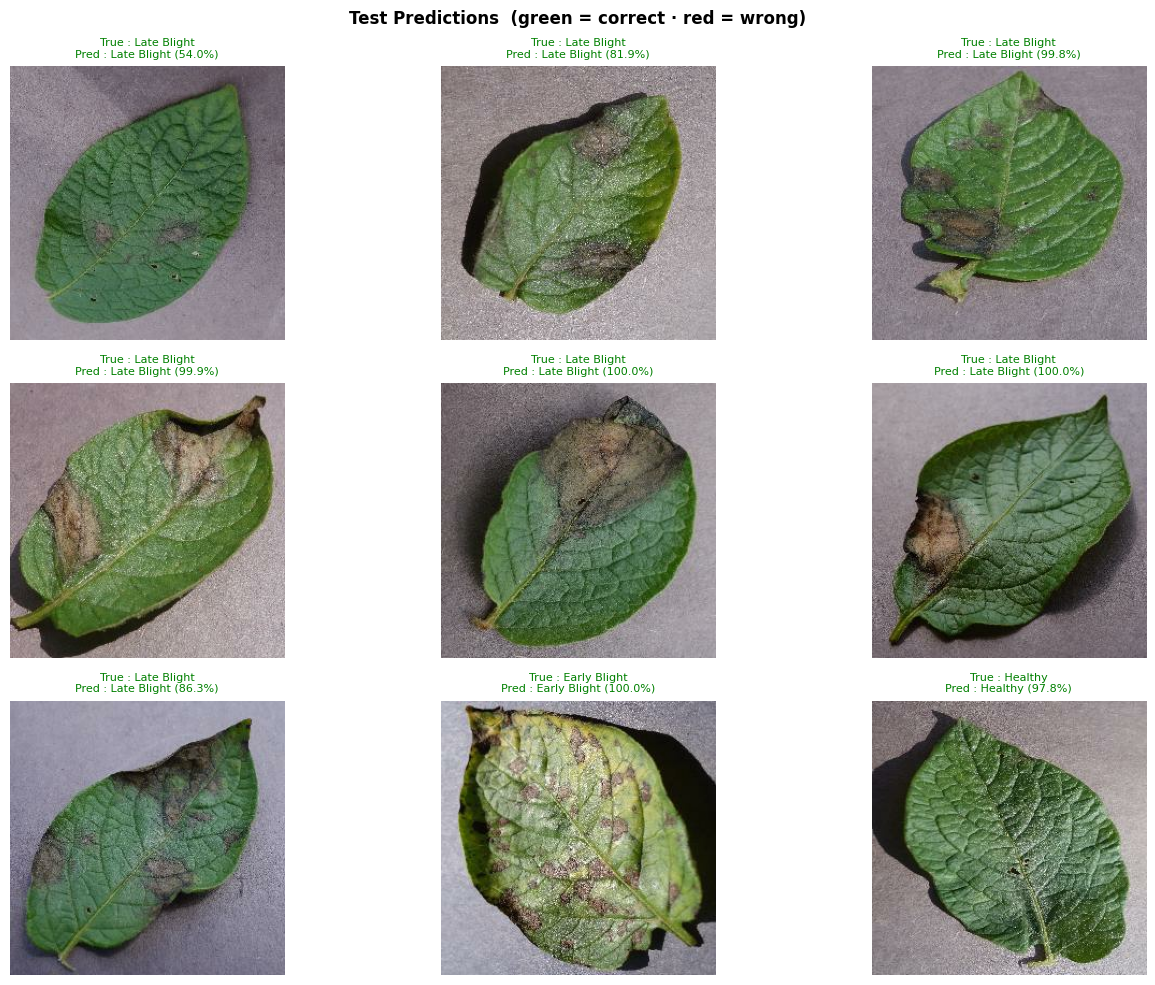

In [12]:
plt.figure(figsize=(14, 10))
count = 0
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, count + 1)
        plt.imshow(images[i].numpy())
        pred_class = CLASS_NAMES[np.argmax(predictions[i])]
        true_class = CLASS_NAMES[labels[i].numpy()]
        confidence = np.max(predictions[i]) * 100
        plt.title(
            f'True : {true_class}\nPred : {pred_class} ({confidence:.1f}%)',
            fontsize=8,
            color='green' if pred_class == true_class else 'red'
        )
        plt.axis('off')
        count += 1
plt.suptitle('Test Predictions  (green = correct · red = wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 11. 🖼️ Predict on Your Own Image

📁 Upload a potato leaf image...


Saving Late Blight 002.jpg to Late Blight 002.jpg


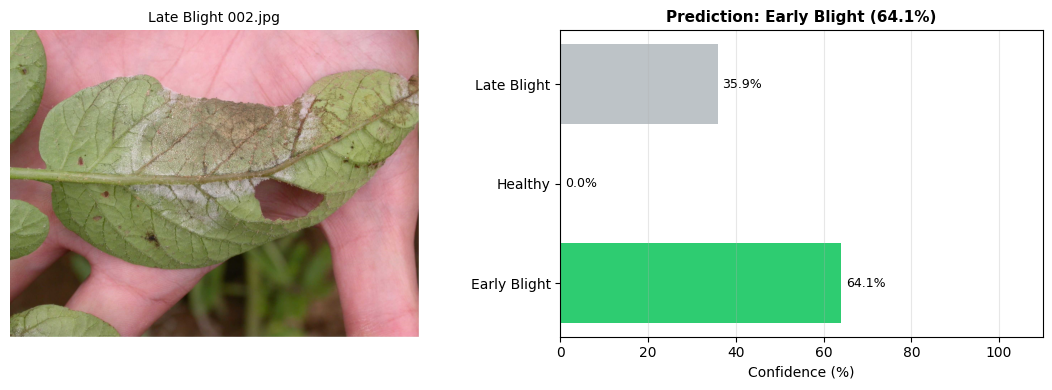

In [13]:
from google.colab import files
from PIL import Image
import io

print('📁 Upload a potato leaf image...')
uploaded = files.upload()

for filename, content in uploaded.items():
    img       = Image.open(io.BytesIO(content)).convert('RGB')
    img_arr   = np.array(img.resize((IMAGE_SIZE, IMAGE_SIZE)), dtype=np.float32) / 255.0
    img_batch = np.expand_dims(img_arr, axis=0)

    prediction = model.predict(img_batch, verbose=0)[0]
    pred_class = CLASS_NAMES[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img)
    axes[0].set_title(filename, fontsize=10)
    axes[0].axis('off')

    colors = ['#2ecc71' if CLASS_NAMES[i] == pred_class else '#bdc3c7'
              for i in range(len(CLASS_NAMES))]
    bars = axes[1].barh(CLASS_NAMES, prediction * 100, color=colors)
    axes[1].set_xlim(0, 110)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Prediction: {pred_class} ({confidence:.1f}%)',
                      fontsize=11, fontweight='bold')
    for bar, val in zip(bars, prediction * 100):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}%', va='center', fontsize=9)
    axes[1].grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


---
## 12. 💾 Save & Download Model

In [16]:
import os

model.save(KERAS_PATH)
print(f'✅ Model saved → {KERAS_PATH}')

SAVED_MODEL_PATH = '/content/saved_model/1'
os.makedirs(SAVED_MODEL_PATH, exist_ok=True)
model.export(SAVED_MODEL_PATH)
print(f'✅ SavedModel saved → {SAVED_MODEL_PATH}')


✅ Model saved → /content/potato_disease_model.keras
Saved artifact at '/content/saved_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136667473437584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136666732247184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136666732246800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136666732248528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136666732248912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136667191854288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136667191854864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136667191856016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136667191856592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136667191857552: TensorSpe

In [17]:
from google.colab import files
files.download(KERAS_PATH)
print('📥 Download started!')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download started!


---
## 13. ♻️ Reload & Verify (Optional)

In [18]:
loaded_model = tf.keras.models.load_model(KERAS_PATH)
print('✅ Model loaded!')
loss, acc = loaded_model.evaluate(test_ds, verbose=0)
print(f'   Test accuracy: {acc * 100:.2f}%')


✅ Model loaded!
   Test accuracy: 91.46%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


---
## 14. 🚀 Deploy — Gradio UI + FastAPI

Runs both services on a single port:
- **`/`** → Gradio web interface
- **`/predict`** → REST API endpoint (POST, multipart image)
- **`/docs`** → Auto-generated Swagger UI
- **`/health`** → Health check


In [19]:
import io, threading, time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gradio as gr
import tensorflow as tf
from PIL import Image as PILImage
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
from pyngrok import ngrok, conf

# ── Constants ──────────────────────────────────────────────────────────────
IMAGE_SIZE  = 256
KERAS_PATH  = '/content/potato_disease_model.keras'
CLASS_NAMES = ['Early Blight', 'Healthy', 'Late Blight']

# ── Load model ─────────────────────────────────────────────────────────────
_model      = None
_model_err  = None
try:
    _model = tf.keras.models.load_model(KERAS_PATH)
    print(f'✅ Model loaded from {KERAS_PATH}')
    print(f'   Input shape : {_model.input_shape}')
    print(f'   Output shape: {_model.output_shape}')
except Exception as e:
    _model_err = str(e)
    print(f'⚠️  Model load failed: {e}')

# ── Disease metadata ───────────────────────────────────────────────────────
DISEASE_INFO = {
    'Early Blight': {
        'emoji': '🟠', 'hex': '#D97706', 'bg': 'rgba(251,191,36,0.10)',
        'border': 'rgba(217,119,6,0.30)', 'badge': 'MODERATE RISK',
        'cause': 'Alternaria solani (Fungus)', 'severity': 'Moderate',
        'icon': '⚠️',
        'symptoms': 'Dark brown circular spots with concentric rings on older leaves, spreading upward.',
        'steps': [
            ('Apply copper-based or chlorothalonil fungicide', '1–2 days'),
            ('Remove and bag all infected leaves', '1–2 days'),
            ('Improve canopy air circulation', '1 week'),
            ('Switch to drip irrigation — keep foliage dry', 'Ongoing'),
        ],
        'urgency': 'Act within 1–2 weeks to prevent spread',
    },
    'Late Blight': {
        'emoji': '🔴', 'hex': '#DC2626', 'bg': 'rgba(220,38,38,0.08)',
        'border': 'rgba(220,38,38,0.30)', 'badge': 'CRITICAL RISK',
        'cause': 'Phytophthora infestans (Oomycete)', 'severity': 'Severe',
        'icon': '🚨',
        'symptoms': 'Water-soaked grey-green lesions rapidly turn brown/black. White mould on leaf undersides.',
        'steps': [
            ('Apply metalaxyl or mancozeb fungicide immediately', 'Today'),
            ('Quarantine and destroy ALL infected material', 'Today'),
            ('Do NOT compost — double-bag and dispose separately', 'Today'),
            ('Notify local agricultural authority if widespread', 'This week'),
        ],
        'urgency': 'Act IMMEDIATELY — spreads explosively in humid weather',
    },
    'Healthy': {
        'emoji': '🟢', 'hex': '#16A34A', 'bg': 'rgba(22,163,74,0.08)',
        'border': 'rgba(22,163,74,0.25)', 'badge': 'ALL CLEAR',
        'cause': 'No pathogen detected', 'severity': 'None',
        'icon': '✅',
        'symptoms': 'Leaf appears vibrant green with uniform colour, no visible lesions or discolouration.',
        'steps': [
            ('Maintain regular watering schedule', 'Ongoing'),
            ('Apply preventive copper-based fungicide spray', 'Every 7–10 days'),
            ('Inspect plants weekly for early warning signs', 'Weekly'),
        ],
        'urgency': 'No immediate action required — keep up preventive care',
    },
}

# ── Chart builder ──────────────────────────────────────────────────────────
def build_chart(predictions, pred_class):
    palette = {
        'Healthy':      ('#16A34A', '#BBF7D0'),
        'Early Blight': ('#D97706', '#FDE68A'),
        'Late Blight':  ('#DC2626', '#FECACA'),
    }
    fig, ax = plt.subplots(figsize=(6.4, 2.6))
    fig.patch.set_facecolor('#FFFFFF')
    ax.set_facecolor('#FAFAFA')
    labels = [f"{DISEASE_INFO[cn]['emoji']}  {cn}" for cn in CLASS_NAMES]
    vals   = predictions * 100
    colors = [palette[cn][0] if cn == pred_class else palette[cn][1] for cn in CLASS_NAMES]
    edges  = [palette[cn][0] for cn in CLASS_NAMES]
    bars   = ax.barh(labels, vals, color=colors, height=0.48, edgecolor=edges, linewidth=0.8, zorder=3)
    for bar, val, cn in zip(bars, vals, CLASS_NAMES):
        ax.text(min(val + 1.5, 112), bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left',
                fontsize=11, fontweight='bold', color=palette[cn][0])
    ax.set_xlim(0, 120)
    ax.set_xlabel('Confidence (%)', fontsize=9, color='#94A3B8', labelpad=6)
    ax.set_title('Prediction Confidence', fontsize=11, fontweight='bold',
                 color='#1E293B', pad=10, loc='left')
    ax.tick_params(axis='y', labelsize=10, colors='#334155')
    ax.tick_params(axis='x', labelsize=8,  colors='#94A3B8')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#E2E8F0')
    ax.grid(axis='x', alpha=0.3, color='#CBD5E1', linestyle='--', zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout(pad=1.0)
    return fig

# ── Shared predict helper ──────────────────────────────────────────────────
def run_inference(pil_img):
    img_rgb     = pil_img.convert('RGB')
    img_resized = img_rgb.resize((IMAGE_SIZE, IMAGE_SIZE), PILImage.LANCZOS)
    arr         = np.array(img_resized, dtype=np.float32) / 255.0
    if arr.shape != (IMAGE_SIZE, IMAGE_SIZE, 3):
        raise ValueError(f'Unexpected shape after resize: {arr.shape}')
    batch       = np.expand_dims(arr, axis=0)
    preds       = _model.predict(batch, verbose=0)[0]
    if len(preds) != len(CLASS_NAMES):
        raise ValueError(f'Model output size {len(preds)} ≠ CLASS_NAMES size {len(CLASS_NAMES)}')
    return preds

# ── Gradio predict function ────────────────────────────────────────────────
PLACEHOLDER = ('<div style="padding:40px;text-align:center;color:#94A3B8;font-size:15px;">'
               '📤 Upload a potato leaf image to get a diagnosis.</div>')

def predict_image(pil_img):
    if pil_img is None:
        return None, PLACEHOLDER
    if _model is None:
        err = (f'<div style="padding:20px;background:rgba(220,38,38,0.08);'
               f'border:1px solid rgba(220,38,38,0.3);border-radius:12px;color:#DC2626;">'
               f'<strong>⚠️ Model not loaded.</strong><br>'
               f'<code>{_model_err}</code><br>'
               f'<small>Run cells 1–12 first, then re-run this deployment cell.</small></div>')
        return None, err
    try:
        preds      = run_inference(pil_img)
        idx        = int(np.argmax(preds))
        pred_class = CLASS_NAMES[idx]
        confidence = float(preds[idx]) * 100
        info       = DISEASE_INFO[pred_class]
        fig        = build_chart(preds, pred_class)
        steps_html = ''.join(
            f'<li style="display:flex;justify-content:space-between;align-items:flex-start;'
            f'padding:9px 0;border-bottom:1px solid rgba(0,0,0,0.05);">'
            f'<span style="color:#334155;font-size:13.5px;line-height:1.5;">{step}</span>'
            f'<span style="background:{info["bg"]};color:{info["hex"]};font-size:11px;'
            f'font-weight:700;padding:3px 10px;border-radius:20px;white-space:nowrap;'
            f'margin-left:14px;border:1px solid {info["border"]}">{tl}</span></li>'
            for step, tl in info['steps']
        )
        html = f"""
<div style="background:{info['bg']};border:1px solid {info['border']};
border-radius:14px;padding:18px 22px;margin-bottom:18px;">
  <div style="display:flex;align-items:center;gap:10px;margin-bottom:8px;">
    <span style="font-size:24px;">{info['icon']}</span>
    <span style="background:{info['hex']};color:white;font-size:10px;font-weight:800;
    letter-spacing:1.4px;padding:3px 12px;border-radius:20px;">{info['badge']}</span>
  </div>
  <h2 style="margin:0 0 5px;font-size:26px;color:{info['hex']};">{info['emoji']} {pred_class}</h2>
  <p style="margin:0;color:#64748B;font-size:13px;">
    Confidence: <strong style="color:{info['hex']}">{confidence:.1f}%</strong>
    &nbsp;·&nbsp; Pathogen: {info['cause']}
    &nbsp;·&nbsp; Severity: <strong style="color:{info['hex']}">{info['severity']}</strong>
  </p>
</div>
<p style="color:#475569;font-size:13.5px;line-height:1.7;margin-bottom:18px;">
  <strong style="color:#1E293B;">Observed symptoms:</strong> {info['symptoms']}
</p>
<h4 style="font-size:11px;color:#94A3B8;letter-spacing:1.2px;margin:0 0 8px;
text-transform:uppercase;font-weight:700;">Recommended Treatment Plan</h4>
<ul style="list-style:none;padding:0;margin:0 0 18px;">{steps_html}</ul>
<div style="display:flex;align-items:center;gap:10px;
background:rgba(255,255,255,0.7);border:1px solid {info['border']};
border-radius:10px;padding:11px 16px;">
  <span style="font-size:17px;">{info['icon']}</span>
  <span style="font-size:13px;color:{info['hex']};font-weight:600;">{info['urgency']}</span>
</div>"""
        return fig, html
    except Exception as exc:
        err = (f'<div style="padding:20px;background:rgba(220,38,38,0.08);'
               f'border:1px solid rgba(220,38,38,0.3);border-radius:12px;color:#DC2626;">'
               f'<strong>⚠️ Prediction error:</strong><br><code>{exc}</code></div>')
        return None, err

# ── CSS ────────────────────────────────────────────────────────────────────
CSS = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@500;700&family=DM+Sans:wght@400;500;600;700&display=swap');
*, *::before, *::after { box-sizing: border-box; }
body, .gradio-container, .gradio-container > .main, #root {
    background: linear-gradient(135deg,#F0F9FF 0%,#FAFAFA 40%,#F0FDF4 100%) !important;
    min-height: 100vh !important;
}
.gradio-container { font-family:'DM Sans',sans-serif !important; max-width:1100px !important; margin:0 auto !important; }
#app-header {
    background:linear-gradient(135deg,rgba(255,255,255,0.85) 0%,rgba(240,253,244,0.80) 100%);
    backdrop-filter:blur(20px) saturate(180%); -webkit-backdrop-filter:blur(20px) saturate(180%);
    border:1px solid rgba(255,255,255,0.6); border-radius:20px; padding:30px 36px;
    margin-bottom:20px; box-shadow:0 8px 32px rgba(0,0,0,0.07); position:relative; overflow:hidden;
}
#app-header h1 { font-family:'Playfair Display',serif !important; font-size:2rem !important;
    color:#0F4C1E !important; margin:0 0 8px !important; letter-spacing:-0.5px !important; }
#app-header p  { color:#4B7A5C !important; font-size:14px !important; margin:0 0 18px !important; }
.badge-pill { display:inline-flex; align-items:center; gap:6px;
    background:rgba(255,255,255,0.7); border:1px solid rgba(0,0,0,0.08);
    color:#374151; font-size:12.5px; padding:5px 14px; border-radius:20px;
    margin-right:6px; margin-bottom:6px; font-weight:500; }
.section-label { font-size:10.5px !important; font-weight:700 !important;
    letter-spacing:1.5px !important; text-transform:uppercase !important;
    color:#94A3B8 !important; margin:0 0 10px !important; }
.upload-zone { background:rgba(255,255,255,0.75) !important;
    border-radius:16px !important; border:1.5px dashed #A7D7B5 !important;
    transition:all 0.25s ease !important; overflow:hidden !important; }
.upload-zone:hover { border-color:#16A34A !important;
    background:rgba(240,253,244,0.85) !important; }
.analyse-btn button {
    background:linear-gradient(135deg,#166534 0%,#16A34A 100%) !important;
    border:none !important; color:white !important;
    font-family:'DM Sans',sans-serif !important; font-size:15px !important;
    font-weight:600 !important; padding:14px 24px !important;
    border-radius:12px !important; width:100% !important; margin-top:12px !important;
    transition:all 0.25s ease !important; cursor:pointer !important;
    box-shadow:0 4px 16px rgba(22,163,74,0.25) !important; }
.analyse-btn button:hover {
    background:linear-gradient(135deg,#15803D 0%,#22C55E 100%) !important;
    transform:translateY(-2px) !important; }
.chart-panel { background:rgba(255,255,255,0.72) !important;
    border-radius:16px !important; border:1px solid rgba(255,255,255,0.60) !important;
    box-shadow:0 4px 24px rgba(0,0,0,0.06) !important; min-height:240px !important; padding:16px !important; }
.diagnosis-box { background:rgba(255,255,255,0.78) !important;
    border-radius:16px !important; border:1px solid rgba(255,255,255,0.65) !important;
    box-shadow:0 4px 24px rgba(0,0,0,0.06) !important; padding:22px !important; margin-top:4px !important; }
.tip-box { background:rgba(240,253,244,0.85) !important;
    border:1px solid rgba(134,239,172,0.5) !important; border-radius:10px !important;
    padding:10px 14px !important; font-size:12.5px !important;
    color:#166534 !important; margin-top:10px !important; line-height:1.5 !important; }
#app-footer { text-align:center; padding:22px; color:#94A3B8; font-size:12px; line-height:1.8; }
#app-footer a { color:#16A34A; text-decoration:none; font-weight:500; }
.gr-box, .gr-form { background:transparent !important; border:none !important; box-shadow:none !important; }
"""

# ── Gradio UI ──────────────────────────────────────────────────────────────
with gr.Blocks(
    css=CSS, title='Potato Disease Detector',
    theme=gr.themes.Base(
        font=[gr.themes.GoogleFont('DM Sans'), 'sans-serif'],
        primary_hue=gr.themes.colors.green,
        neutral_hue=gr.themes.colors.slate,
    ),
) as demo:

    gr.HTML("""
    <div id="app-header">
      <h1>🌿 Potato Leaf Disease Detector</h1>
      <p>AI-powered diagnosis · Custom TensorFlow CNN · Tracked with Weights &amp; Biases</p>
      <div>
        <span class="badge-pill">🟢 Healthy</span>
        <span class="badge-pill">🟠 Early Blight</span>
        <span class="badge-pill">🔴 Late Blight</span>
      </div>
    </div>
    """)

    with gr.Row(equal_height=False):
        with gr.Column(scale=1, min_width=280):
            gr.HTML('<p class="section-label">📤 Upload Leaf Image</p>')
            image_input = gr.Image(
                type='pil', label='', height=280,
                sources=['upload', 'clipboard'],
                elem_classes='upload-zone',
                show_label=False, image_mode='RGB',
            )
            predict_btn = gr.Button('🔍  Analyse Image', variant='primary',
                                    elem_classes='analyse-btn')
            gr.HTML('<div class="tip-box">💡 <strong>Best results:</strong> Close-up of a single leaf in good lighting. Supports JPG, PNG, WEBP.</div>')

        with gr.Column(scale=1, min_width=280):
            gr.HTML('<p class="section-label">📊 Confidence Breakdown</p>')
            chart_output = gr.Plot(label='', show_label=False, elem_classes='chart-panel')

    with gr.Row():
        with gr.Column():
            gr.HTML('<p class="section-label" style="margin-top:18px;">🩺 Diagnosis Report</p>')
            with gr.Group(elem_classes='diagnosis-box'):
                result_output = gr.HTML(value=PLACEHOLDER)

    with gr.Accordion('🧠  Model Architecture & Training Pipeline', open=False):
        gr.HTML("""
        <div style="font-family:'DM Sans',sans-serif;padding:4px 0;">
          <div style="display:flex;flex-wrap:wrap;gap:8px;align-items:center;justify-content:center;margin-bottom:20px;">
            <div style="background:rgba(239,246,255,0.9);border:1px solid #BFDBFE;border-radius:12px;padding:12px 16px;text-align:center;min-width:90px;">
              <div style="font-size:22px;">📷</div><div style="font-size:12px;font-weight:700;color:#1D4ED8;margin-top:4px;">Input</div>
              <div style="font-size:11px;color:#6B7280;">256 × 256 px</div></div>
            <div style="color:#CBD5E1;font-size:20px;">→</div>
            <div style="background:rgba(253,244,255,0.9);border:1px solid #E9D5FF;border-radius:12px;padding:12px 16px;text-align:center;min-width:90px;">
              <div style="font-size:22px;">🔄</div><div style="font-size:12px;font-weight:700;color:#7C3AED;margin-top:4px;">Augment</div>
              <div style="font-size:11px;color:#6B7280;">Flip · Rotate · Zoom</div></div>
            <div style="color:#CBD5E1;font-size:20px;">→</div>
            <div style="background:rgba(240,253,244,0.9);border:1px solid #BBF7D0;border-radius:12px;padding:12px 16px;text-align:center;min-width:90px;">
              <div style="font-size:22px;">🔲</div><div style="font-size:12px;font-weight:700;color:#15803D;margin-top:4px;">Conv ×6</div>
              <div style="font-size:11px;color:#6B7280;">32 → 64 filters</div></div>
            <div style="color:#CBD5E1;font-size:20px;">→</div>
            <div style="background:rgba(255,251,235,0.9);border:1px solid #FDE68A;border-radius:12px;padding:12px 16px;text-align:center;min-width:90px;">
              <div style="font-size:22px;">🔗</div><div style="font-size:12px;font-weight:700;color:#B45309;margin-top:4px;">Dense</div>
              <div style="font-size:11px;color:#6B7280;">64 units · 0.3 drop</div></div>
            <div style="color:#CBD5E1;font-size:20px;">→</div>
            <div style="background:rgba(255,241,242,0.9);border:1px solid #FECDD3;border-radius:12px;padding:12px 16px;text-align:center;min-width:90px;">
              <div style="font-size:22px;">🎯</div><div style="font-size:12px;font-weight:700;color:#B91C1C;margin-top:4px;">Softmax</div>
              <div style="font-size:11px;color:#6B7280;">3 classes</div></div>
          </div>
          <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(180px,1fr));gap:10px;">
            <div style="background:rgba(248,250,252,0.85);border-radius:10px;padding:13px;border-left:3px solid #3B82F6;">
              <div style="font-size:10.5px;font-weight:700;color:#3B82F6;letter-spacing:1px;">DATASET</div>
              <div style="font-size:12px;color:#475569;margin-top:5px;line-height:1.5;">PlantVillage via TF Datasets<br>~3,000 potato leaf images</div></div>
            <div style="background:rgba(248,250,252,0.85);border-radius:10px;padding:13px;border-left:3px solid #10B981;">
              <div style="font-size:10.5px;font-weight:700;color:#10B981;letter-spacing:1px;">TRAINING</div>
              <div style="font-size:12px;color:#475569;margin-top:5px;line-height:1.5;">Adam · EarlyStopping<br>ReduceLROnPlateau · Class Weights</div></div>
            <div style="background:rgba(248,250,252,0.85);border-radius:10px;padding:13px;border-left:3px solid #F59E0B;">
              <div style="font-size:10.5px;font-weight:700;color:#F59E0B;letter-spacing:1px;">TRACKING</div>
              <div style="font-size:12px;color:#475569;margin-top:5px;line-height:1.5;">Weights &amp; Biases<br>metrics, checkpoints &amp; artifacts</div></div>
          </div>
        </div>
        """)

    gr.HTML("""
    <div id="app-footer">
      Built with <a href="https://tensorflow.org" target="_blank">TensorFlow</a> ·
      <a href="https://gradio.app" target="_blank">Gradio</a> ·
      <a href="https://fastapi.tiangolo.com" target="_blank">FastAPI</a> ·
      <a href="https://wandb.ai" target="_blank">Weights &amp; Biases</a><br>
      Dataset: <a href="https://www.tensorflow.org/datasets/catalog/plant_village" target="_blank">PlantVillage</a>
      &nbsp;·&nbsp; ⚠️ For educational purposes only.
    </div>
    """)

    _outs = [chart_output, result_output]
    predict_btn.click(fn=predict_image, inputs=[image_input], outputs=_outs)
    image_input.change(fn=predict_image, inputs=[image_input], outputs=_outs)


# ── FastAPI app ────────────────────────────────────────────────────────────
fastapi_app = FastAPI(
    title='Potato Disease API',
    description='Potato leaf disease classification — Early Blight / Late Blight / Healthy',
    version='1.0',
)
fastapi_app.add_middleware(
    CORSMiddleware, allow_origins=['*'],
    allow_methods=['*'], allow_headers=['*'],
)

@fastapi_app.get('/health')
def health():
    return {'status': 'ok', 'model': 'loaded' if _model is not None else 'not_loaded'}

@fastapi_app.post('/predict')
async def predict_endpoint(file: UploadFile = File(...)):
    if _model is None:
        raise HTTPException(status_code=503, detail=f'Model not loaded: {_model_err}')
    if not file.content_type.startswith('image/'):
        raise HTTPException(status_code=400, detail='File must be an image')
    content = await file.read()
    try:
        pil_img = PILImage.open(io.BytesIO(content))
        preds   = run_inference(pil_img)
        idx     = int(np.argmax(preds))
        return {
            'prediction':    CLASS_NAMES[idx],
            'confidence':    round(float(preds[idx]) * 100, 2),
            'probabilities': {CLASS_NAMES[i]: round(float(preds[i]) * 100, 2)
                              for i in range(len(CLASS_NAMES))},
            'disease_info': {
                'cause':    DISEASE_INFO[CLASS_NAMES[idx]]['cause'],
                'severity': DISEASE_INFO[CLASS_NAMES[idx]]['severity'],
                'urgency':  DISEASE_INFO[CLASS_NAMES[idx]]['urgency'],
            },
        }
    except Exception as exc:
        raise HTTPException(status_code=500, detail=str(exc))

fastapi_app = gr.mount_gradio_app(fastapi_app, demo, path='/')

print('✅ Gradio + FastAPI app built.')
print(f'   Routes: / (UI)  /predict (POST)  /health (GET)  /docs (Swagger)')


✅ Model loaded from /content/potato_disease_model.keras
   Input shape : (None, 256, 256, 3)
   Output shape: (None, 3)


/tmp/ipykernel_3200/1815409620.py:242: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_3200/1815409620.py:242: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


new /
✅ Gradio + FastAPI app built.
   Routes: / (UI)  /predict (POST)  /health (GET)  /docs (Swagger)


---
## 15. 🌐 Launch Public URL

In [20]:
PORT = 8000

def run_server():
    uvicorn.run(fastapi_app, host='0.0.0.0', port=PORT, log_level='error')

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(4)

conf.get_default().auth_token = NGROK_TOKEN
ngrok.kill()
time.sleep(1)

public_url = ngrok.connect(PORT, bind_tls=True)

print('\n' + '='*60)
print('  🌐  POTATO DISEASE DETECTOR IS LIVE!')
print('='*60)
print(f'  🖥️   UI      → {public_url}/')
print(f'  🔌  API     → {public_url}/predict')
print(f'  📖  Docs    → {public_url}/docs')
print(f'  🏥  Health  → {public_url}/health')
print('='*60)
print('  Share the UI url — accessible worldwide while this cell runs.')
print('='*60)


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use



  🌐  POTATO DISEASE DETECTOR IS LIVE!
  🖥️   UI      → NgrokTunnel: "https://subhexagonal-conical-henriette.ngrok-free.dev" -> "http://localhost:8000"/
  🔌  API     → NgrokTunnel: "https://subhexagonal-conical-henriette.ngrok-free.dev" -> "http://localhost:8000"/predict
  📖  Docs    → NgrokTunnel: "https://subhexagonal-conical-henriette.ngrok-free.dev" -> "http://localhost:8000"/docs
  🏥  Health  → NgrokTunnel: "https://subhexagonal-conical-henriette.ngrok-free.dev" -> "http://localhost:8000"/health
  Share the UI url — accessible worldwide while this cell runs.
